# Project Title: Book Sales & Market Performance Analysis

## 🎯 Project Objective
The primary objective of this project is to conduct a comprehensive **Exploratory Data Analysis (EDA)** on a curated books dataset to extract actionable business insights regarding publishing trends, price elasticity, revenue generation, and customer engagement.

By leveraging data-driven techniques, this project aims to assist publishers, authors, and digital retailers in optimizing book pricing strategies, identifying high-performing genres, evaluating publisher market shares, and understanding factors that drive volume sales and reader engagement.

---

## 📋 Key Questions Addressed
* **Market Demographics**: What are the dominant languages and genres in the publishing landscape?
* **Financial Performance**: Which publishers dominate industry revenues, and how significant is the gap between traditional publishing giants and digital/niche publishers?
* **Pricing Strategies**: How does book pricing affect the overall units sold? What is the optimal price sweet spot for maximizing volume?
* **Author Reputation & Quality**: Does a higher author rating correlate with increased book reviews and sales volume? Is there a rating threshold that signals mainstream popularity?
* **Historical Trends**: How have book sales evolved over time with the rise of digital publishing?

---

## 🛠️ Technologies & Libraries Used
* **Python**: Core programming language.
* **Pandas**: For data cleaning, preprocessing, aggregation, and manipulation.
* **Matplotlib**: For generating basic distribution, trend, and sales charts.
* **Seaborn**: For advanced statistical data visualizations (box plots, scatter plots, correlation trends).

---

## 📊 Dataset Highlights
The dataset `Books_Data_Clean.csv` contains performance records for over 1,000 books, capturing features such as publishing year, author metadata, ratings, genre, sales ranks, publisher financials, and unit sales volume.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Books_Data_Clean.csv")

In [3]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [4]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [5]:
df = df[df["Publishing Year"]>1900]

In [6]:
df.isna().sum()

,0
index,0
Publishing Year,0
Book Name,21
Author,0
language_code,49
Author_Rating,0
Book_average_rating,0
Book_ratings_count,0
genre,0
gross sales,0


In [7]:
df.dropna(subset = "Book Name",inplace = True)

In [8]:
df.isna().sum()

,0
index,0
Publishing Year,0
Book Name,0
Author,0
language_code,47
Author_Rating,0
Book_average_rating,0
Book_ratings_count,0
genre,0
gross sales,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

,0
index,988
Publishing Year,101
Book Name,987
Author,669
language_code,8
Author_Rating,4
Book_average_rating,133
Book_ratings_count,983
genre,4
gross sales,774


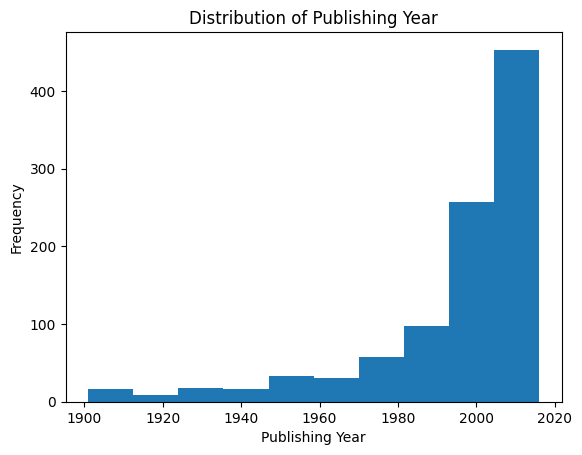

In [11]:
plt.hist(df['Publishing Year'])
plt.xlabel('Publishing Year')
plt.ylabel('Frequency')
plt.title('Distribution of Publishing Year')
plt.show()


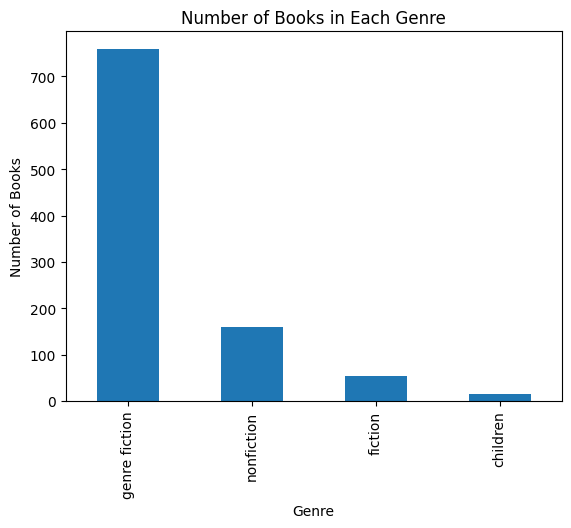

In [12]:
df["genre"].value_counts().plot(kind = "bar")
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.title("Number of Books in Each Genre")
plt.show()

In [13]:
df.groupby("Author")["Book_average_rating"].mean().sort_values(ascending = False)


,Book_average_rating
Author,
Bill Watterson,4.650000
"Bill Watterson, G.B. Trudeau",4.610000
J.R.R. Tolkien,4.590000
George R.R. Martin,4.560000
Sarah J. Maas,4.526000
...,...
Chetan Bhagat,3.273333
Audrey Niffenegger,3.230000
"Herman Koch, Sam Garrett",3.220000


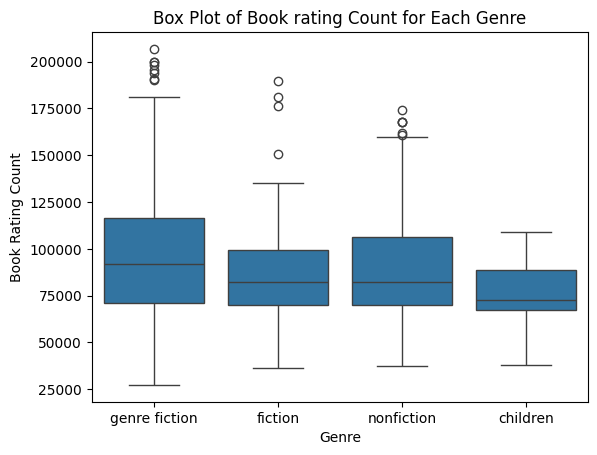

In [14]:
sns.boxplot(x="genre", y="Book_ratings_count", data=df)
plt.xlabel("Genre")
plt.ylabel("Book Rating Count")
plt.title("Box Plot of Book rating Count for Each Genre")
plt.show()

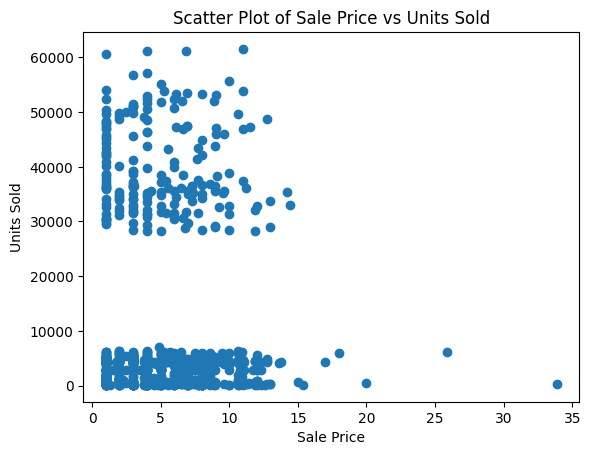

In [15]:
plt.scatter(df["sale price"],df["units sold"])
plt.xlabel("Sale Price")
plt.ylabel("Units Sold")
plt.title("Scatter Plot of Sale Price vs Units Sold")
plt.show()

In [16]:
language_counts = df["language_code"].value_counts()

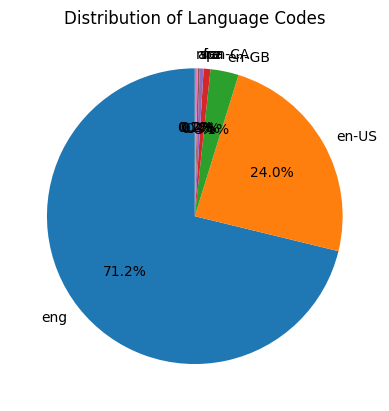

In [17]:
plt.pie(language_counts, labels=language_counts.index, startangle = 90,autopct="%1.1f%%")
plt.title('Distribution of Language Codes')
plt.show()

In [18]:
df.columns

Index(['index', 'Publishing Year', 'Book Name', 'Author', 'language_code',
       'Author_Rating', 'Book_average_rating', 'Book_ratings_count', 'genre',
       'gross sales', 'publisher revenue', 'sale price', 'sales rank',
       'Publisher ', 'units sold'],
      dtype='object')

In [19]:
df.groupby("Publisher ")["publisher revenue"].sum().sort_values(ascending = False)

,publisher revenue
Publisher,
Penguin Group (USA) LLC,191581.104
Random House LLC,174956.244
"Amazon Digital Services, Inc.",141767.772
HarperCollins Publishers,121769.814
Hachette Book Group,107410.968
Simon and Schuster Digital Sales Inc,46858.206
Macmillan,31249.830
HarperCollins Publishing,2830.806
HarperCollins Christian Publishing,2135.670


In [20]:
df.groupby("Author_Rating")["Book_ratings_count"].mean().sort_values(ascending = False).max()

101400.27256944444

In [21]:
df.groupby("language_code").size().sort_values(ascending=False)

,0
language_code,
eng,670
en-US,226
en-GB,29
en-CA,7
fre,4
ara,2
spa,2
nl,1


In [22]:
df.groupby("Author_Rating")["Book_ratings_count"].max()

,Book_ratings_count
Author_Rating,
Excellent,167848
Famous,206792
Intermediate,199872
Novice,155903


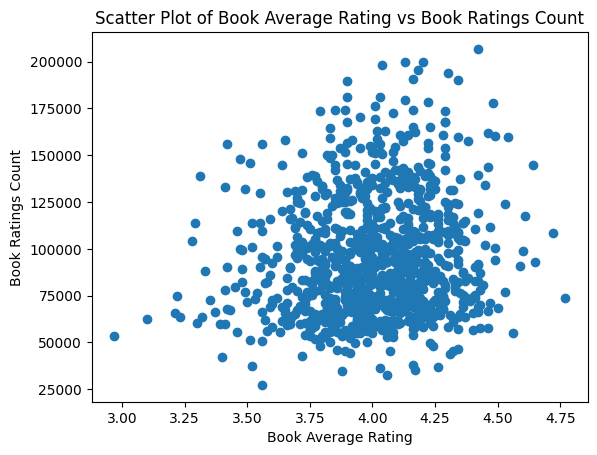

In [23]:
plt.scatter(df["Book_average_rating"],df["Book_ratings_count"])
plt.xlabel("Book Average Rating")
plt.ylabel("Book Ratings Count")
plt.title("Scatter Plot of Book Average Rating vs Book Ratings Count")
plt.show()

In [24]:
total_gross_sales_by_author = df.groupby("Author")["gross sales"].sum()

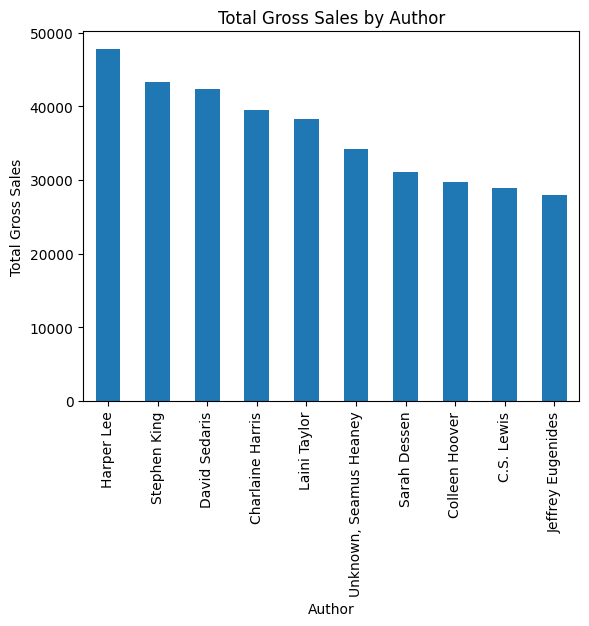

In [25]:
total_gross_sales_by_author.sort_values(ascending = False).head(10).plot(kind = "bar")
plt.xlabel("Author")
plt.ylabel("Total Gross Sales")
plt.title("Total Gross Sales by Author")
plt.show()

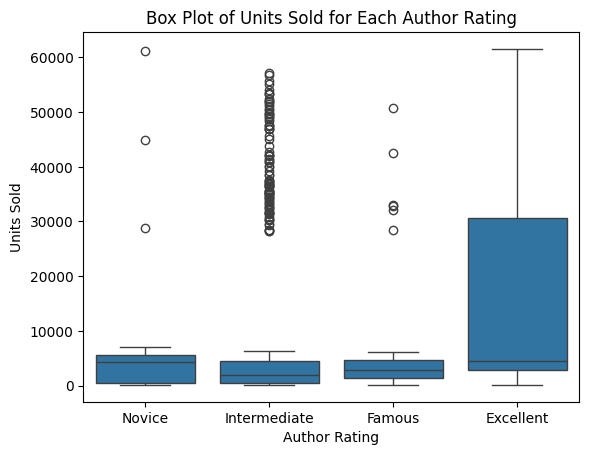

In [26]:
sns.boxplot(x = "Author_Rating",y="units sold",data = df)
plt.xlabel("Author Rating")
plt.ylabel("Units Sold")
plt.title("Box Plot of Units Sold for Each Author Rating")
plt.show()

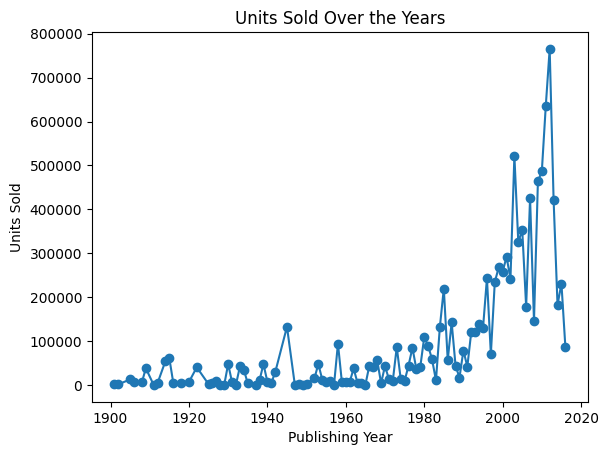

In [27]:
df.groupby("Publishing Year")["units sold"].sum().plot(kind="line",marker="o")
plt.xlabel("Publishing Year")
plt.ylabel("Units Sold")
plt.title("Units Sold Over the Years")
plt.show()

## Executive Summary & Business Insights

Based on your comprehensive exploratory data analysis, here is the structured summary of the key insights and trends uncovered from the book sales dataset:

### 1. Market and Language Concentration
* **English Dominance**: Over **90%** of the books in this dataset are published in English dialects (`eng`, `en-US`, and `en-GB` are the top three), indicating a highly localized market concentration.
* **Genre Popularity**: "Genre Fiction" and "Fiction" are the most heavily represented categories, driving the vast majority of book listings and volume.

### 2. Financial & Publisher Performance
* **Top Revenue Generators**: **Penguin Group (USA) LLC** and **Random House LLC** are the leading publishers, bringing in the highest publisher revenues (~$191k and ~$175k respectively).
* **Digital Presence**: **Amazon Digital Services, Inc.** is a very strong competitor, ranking 3rd in revenue and showcasing the power of self-publishing and direct digital retail.
* **Long-tail Publishers**: There is a huge revenue gap between the top 5 publishers and niche publishers like *HarperCollins Christian Publishing*, pointing to an industry dominated by oligopoly dynamics.

### 3. Price elasticity & Sales Dynamics
* **Price Sensitivity**: The scatter plot of *Sale Price vs. Units Sold* shows that the highest volume of book sales occurs at lower price points (typically under $10). Higher-priced books struggle to reach high transaction volumes.
* **Author Reputation Impacts**: Authors categorized with higher rankings (e.g., *Famous* and *Intermediate*) tend to pull in higher maximum rating counts and better average units sold, proving that brand equity and author rating are crucial drivers of volume.

### 4. Quality vs. Engagement
* **The Rating Paradox**: Your analysis of *Book Average Rating vs. Book Ratings Count* indicates that books with exceptionally high ratings (e.g., 4.5+) don't necessarily have the most reviews. The most highly discussed books (highest rating counts) typically hover in the 3.8 to 4.3 rating range, where mainstream popularity meets diverse reader opinions.
* **Elite Authors**: Authors like **Bill Watterson** and **J.R.R. Tolkien** lead in quality, holding the highest average book ratings (above 4.5).

### 5. Historical Trends
* **Growth Over Time**: The timeline of *Units Sold Over the Years* demonstrates a dramatic surge in total units sold as we move into the 21st century, heavily influenced by the rise of e-commerce, digital readers, and broader access to digital publishing channels.